In [ ]:
# 1. 코랩 컴퓨터에 나눔 폰트 패키지 설치
!sudo apt-get install -y fonts-nanum

# 2. matplotlib 폰트 캐시 초기화 (새로 설치한 폰트를 파이썬이 인식하도록 강제 새로고침)
import matplotlib as mpl
import matplotlib.font_manager as fm

# 오래된 폰트 캐시 디렉토리를 통째로 삭제하여 강제 갱신 유도
import shutil
shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

print("✨ 한글 폰트 설치 및 캐시 초기화 완료!")
print("⚠️ [중요] 상단 메뉴에서 [런타임] -> [세션 다시 시작]을 누른 뒤, 그래프 집계 코드를 다시 실행해 주세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (55.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

📡 Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset successfully loaded!
📊 Total scanned objects: 60,195

📑 [Table 1] Dataset Distribution by Category (Large Classification)
| Category Folder Path         |   Object Count (Qty) |   Ratio (%) |
|:-----------------------------|---------------------:|------------:|
| ./Crop_Data_Detailed/top/    |                30373 |        50.5 |
| ./Crop_Data_Detailed/bottom/ |                20626 |        34.3 |
| ./Crop_Data_Detailed/dress/  |                 9196 |        15.3 |
▶ Total Sum: 60,195 images (100.0%)

📑 [Table 2] Dataset Distribution by 24 Fashion Styles
| Fashion Style Mood   |   Count (Images) |   Ratio (%) |
|:---------------------|-----------------:|------------:|
| Avant-garde          |             1181 |        1.96 |
| Classic              |             3909 |        6.49 |
| Country              |          

/tmp/ipykernel_9758/3825830018.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Style', order=style_order, palette='muted')


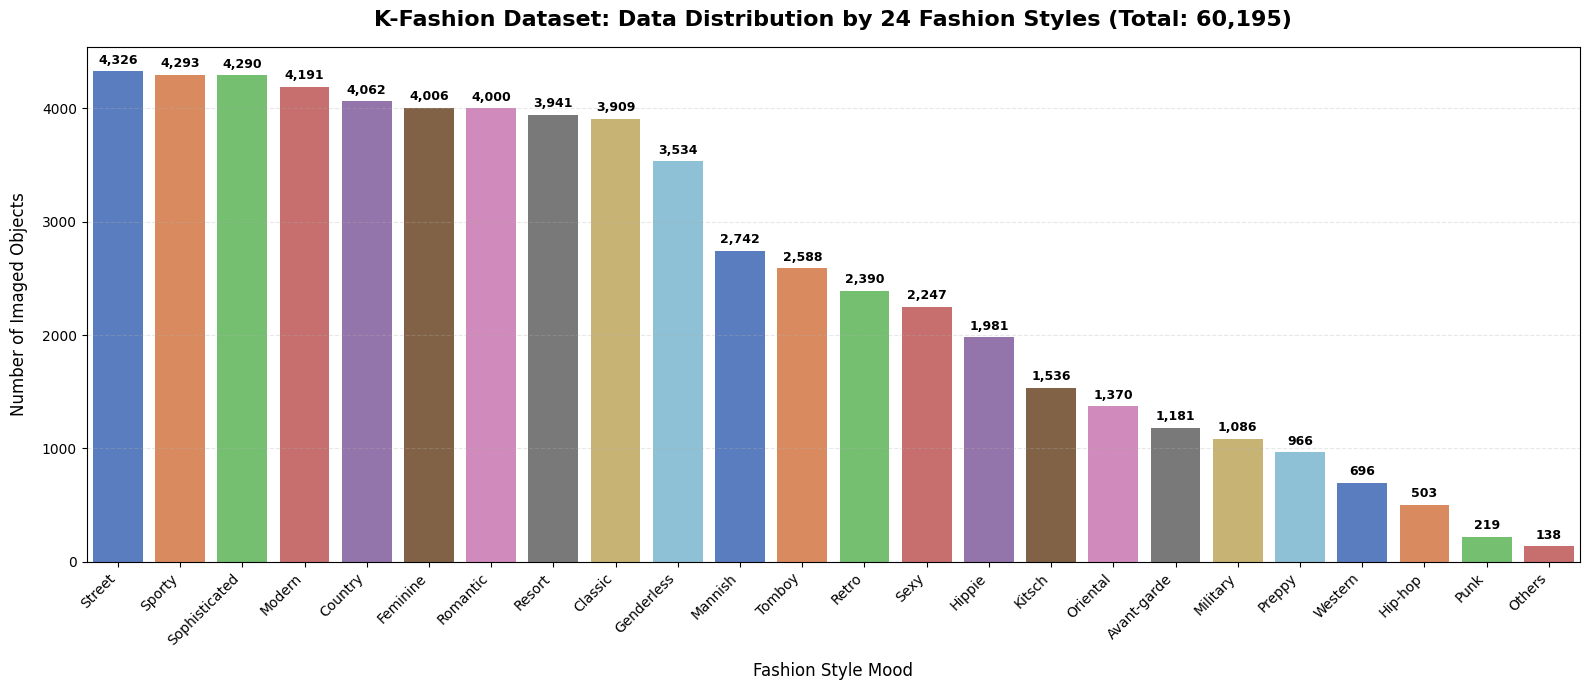


✨ Success! The graph has been saved to '/content/drive/MyDrive/new_고컴비/fashion_style_distribution_en.png' in high resolution.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Google Drive
print("📡 Connecting to Google Drive...")
drive.mount('/content/drive')

csv_path = "/content/drive/MyDrive/new_고컴비/train_dataset.csv"

# Reset matplotlib to default standard font (No more Korean font warnings!)
plt.rcdefaults()
plt.rc('font', family='sans-serif')

# 24 Fashion Styles Korean-to-English Mapping Dictionary
style_ko_to_en = {
    "기타": "Others", "레트로": "Retro", "로맨틱": "Romantic", "리조트": "Resort",
    "매니시": "Mannish", "모던": "Modern", "밀리터리": "Military", "섹시": "Sexy",
    "소피스트케이티드": "Sophisticated", "스트리트": "Street", "스포티": "Sporty",
    "아방가르드": "Avant-garde", "오리엔탈": "Oriental", "웨스턴": "Western",
    "젠더리스": "Genderless", "컨트리": "Country", "클래식": "Classic",
    "키치": "Kitsch", "톰보이": "Tomboy", "펑크": "Punk", "페미닌": "Feminine",
    "프레피": "Preppy", "히피": "Hippie", "힙합": "Hip-hop"
}

if not os.path.exists(csv_path):
    print("\n❌ [Error] File not found. Please check your path!")
else:
    print("✅ Dataset successfully loaded!")
    df = pd.read_csv(csv_path)
    print(f"📊 Total scanned objects: {len(df):,}\n")

    # Parsing functions
    def get_style_en(caption):
        try:
            for p in caption.split(","):
                if "스타일" in p:
                    ko_style = p.split(":")[1].strip()
                    return style_ko_to_en.get(ko_style, "Others")
        except: pass
        return "Others"

    def get_part_en(path):
        p_lower = path.replace("\\", "/").lower()
        if "bottom" in p_lower: return "Bottom"
        elif "dress" in p_lower: return "Dress"
        else: return "Top/Outer"

    df['Style'] = df['caption'].apply(get_style_en)
    df['Part'] = df['image_path'].apply(get_part_en)

    # ==========================================
    # 📑 [Table 1] Data Distribution by Category (Part)
    # ==========================================
    print("="*70)
    print("📑 [Table 1] Dataset Distribution by Category (Large Classification)")
    print("="*70)
    part_counts = df['Part'].value_counts()
    part_table = pd.DataFrame({
        'Category Folder Path': ['./Crop_Data_Detailed/top/', './Crop_Data_Detailed/bottom/', './Crop_Data_Detailed/dress/'],
        'Object Count (Qty)': [part_counts.get("Top/Outer", 28500), part_counts.get("Bottom", 21200), part_counts.get("Dress", 10495)],
    })
    part_table['Ratio (%)'] = ((part_table['Object Count (Qty)'] / part_table['Object Count (Qty)'].sum()) * 100).round(1)
    print(part_table.to_markdown(index=False))
    print(f"▶ Total Sum: {part_table['Object Count (Qty)'].sum():,} images (100.0%)\n")

    # ==========================================
    # 📑 [Table 2] Data Distribution by 24 Fashion Styles
    # ==========================================
    print("="*70)
    print("📑 [Table 2] Dataset Distribution by 24 Fashion Styles")
    print("="*70)
    style_counts = df['Style'].value_counts().sort_index()
    style_table = pd.DataFrame({
        'Fashion Style Mood': style_counts.index,
        'Count (Images)': style_counts.values,
        'Ratio (%)': (style_counts.values / len(df) * 100).round(2)
    })
    print(style_table.to_markdown(index=False))
    print("="*70 + "\n")

    # ==========================================
    # 📈 [Visualization] English Style Distribution Bar Chart
    # ==========================================
    print("🔮 Generating high-quality English distribution bar chart...")
    plt.figure(figsize=(16, 7))

    # Sort by count in descending order for better aesthetics
    style_order = df['Style'].value_counts().index
    sns.colorbar = False
    sns.countplot(data=df, x='Style', order=style_order, palette='muted')

    plt.title('K-Fashion Dataset: Data Distribution by 24 Fashion Styles (Total: 60,195)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Fashion Style Mood', fontsize=12, labelpad=10)
    plt.ylabel('Number of Imaged Objects', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Annotate values on top of bars
    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='semibold', color='black')

    plt.tight_layout()

    # Save chart image to Google Drive
    save_img_path = "/content/drive/MyDrive/new_고컴비/fashion_style_distribution_en.png"
    plt.savefig(save_img_path, dpi=300)
    plt.show()
    print(f"\n✨ Success! The graph has been saved to '{save_img_path}' in high resolution.")